In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix,
                            r2_score, mean_squared_error, mean_absolute_error)
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [317]:
df = pd.read_csv("shopping_trends_updated.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [318]:
# Feature Engineering

# 1. Monetary Features
df['customer_value'] = df['Previous Purchases'] * df['Purchase Amount (USD)']
df['avg_purchase_amount'] = df['Purchase Amount (USD)'] / (df['Previous Purchases'] + 1)

# 2. Frequency Features
freq_map = {'Weekly': 52, 'Bi-Weekly': 26, 'Fortnightly': 26, 
            'Monthly': 12, 'Quarterly': 4, 'Annually': 1}
df['purchase_freq'] = df['Frequency of Purchases'].map(freq_map).fillna(0)
df['total_annual_spend'] = df['avg_purchase_amount'] * df['purchase_freq']

# 3. Customer Behavior Indicators
df['is_high_spender'] = (df['Purchase Amount (USD)'] > 75).astype(int)
df['is_frequent_buyer'] = (df['purchase_freq'] >= 12).astype(int)
df['has_subscription'] = (df['Subscription Status'] == 'Yes').astype(int)

# 4. Price Sensitivity
df['uses_promo'] = (df['Promo Code Used'] != 'No').astype(int)
df['discount_applied'] = (df['Discount Applied'] ==  'Yes').astype(int)
df['price_sensitive'] = ((df['uses_promo'] == 1) | (df['discount_applied'] == 1)).astype(int)

# Check for any remaining NaN values
print(f"NaN values in dataset: {df.isnull().sum().sum()}")
print(f"\nOriginal features: 18")
print(f"Engineered features: 10")
print(f"Total features: {len(df.columns)}")

NaN values in dataset: 0

Original features: 18
Engineered features: 10
Total features: 28


In [ ]:
# Data preprocessing

# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

median_amt = df['Purchase Amount (USD)'].median()
df['target'] = (df['Purchase Amount (USD)'] > median_amt).astype(int)

# Fill any remaining NaN values with 0
df = df.fillna(0)

print(f"Target distribution:")
print(df['target'].value_counts())
print(f"\nMedian threshold: ${median_amt:.2f}")
print(f"Total NaN values after preprocessing: {df.isnull().sum().sum()}")

Target distribution:
target
0    1986
1    1914
Name: count, dtype: int64

Median threshold: $60.00
Total NaN values after preprocessing: 0


In [320]:
X = df.drop(['Customer ID', 'Purchase Amount (USD)', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 3120, Test: 780


In [321]:
# Train classification models

rf_model = RandomForestClassifier(
    n_estimators=50,          
    max_depth=5,              
    min_samples_split=20,     
    min_samples_leaf=10,     
    random_state=RANDOM_STATE
)

gb_model = GradientBoostingClassifier(
    n_estimators=50,          
    learning_rate=0.05,       
    max_depth=3,              
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

dt_model = DecisionTreeClassifier(
    max_depth=5,              
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

xgb_model = xgb.XGBClassifier(
    n_estimators=50,          
    max_depth=4,              
    learning_rate=0.05,       
    min_child_weight=5,       
    subsample=0.8,            
    colsample_bytree=0.8,     
    random_state=RANDOM_STATE,
    verbosity=0
)

lgb_model = lgb.LGBMClassifier(
    n_estimators=50,          
    max_depth=4,              
    learning_rate=0.05,       
    min_child_samples=20,     
    subsample=0.8,            
    colsample_bytree=0.8,    
    random_state=RANDOM_STATE,
    verbose=-1
)

# Train ALL 5 models
print("Training Random Forest")
rf_model.fit(X_train, y_train)

print("Training Gradient Boosting")
gb_model.fit(X_train, y_train)

print("Training Decision Tree")
dt_model.fit(X_train, y_train)

print("Training XGBoost")
xgb_model.fit(X_train, y_train)

print("Training LightGBM")
lgb_model.fit(X_train, y_train)

print("\n✅ All 5 ensemble models trained successfully!")

Training Random Forest
Training Gradient Boosting
Training Decision Tree
Training XGBoost
Training LightGBM

✅ All 5 ensemble models trained successfully!


In [322]:
# Evaluate classification models

results = []
models_dict = {
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'Decision Tree': dt_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

for name, model in models_dict.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'AUC-ROC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results)
print("="*70)
print("ENSEMBLE LEARNING - CLASSIFICATION MODEL PERFORMANCE")
print("="*70)
print(results_df.to_string(index=False))

# Identify best model
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score: {results_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"   Accuracy: {results_df.loc[best_idx, 'Accuracy']*100:.2f}%")
print(f"{'='*70}")

ENSEMBLE LEARNING - CLASSIFICATION MODEL PERFORMANCE
            Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
    Random Forest  0.894872   0.980831 0.801567  0.882184 0.982078
Gradient Boosting  0.941026   0.985591 0.892950  0.936986 0.994637
    Decision Tree  0.938462   0.974504 0.898172  0.934783 0.981628
          XGBoost  0.941026   0.980057 0.898172  0.937330 0.994124
         LightGBM  0.947436   0.983051 0.908616  0.944369 0.995436

🏆 BEST MODEL: LightGBM
   F1-Score: 0.9444
   Accuracy: 94.74%


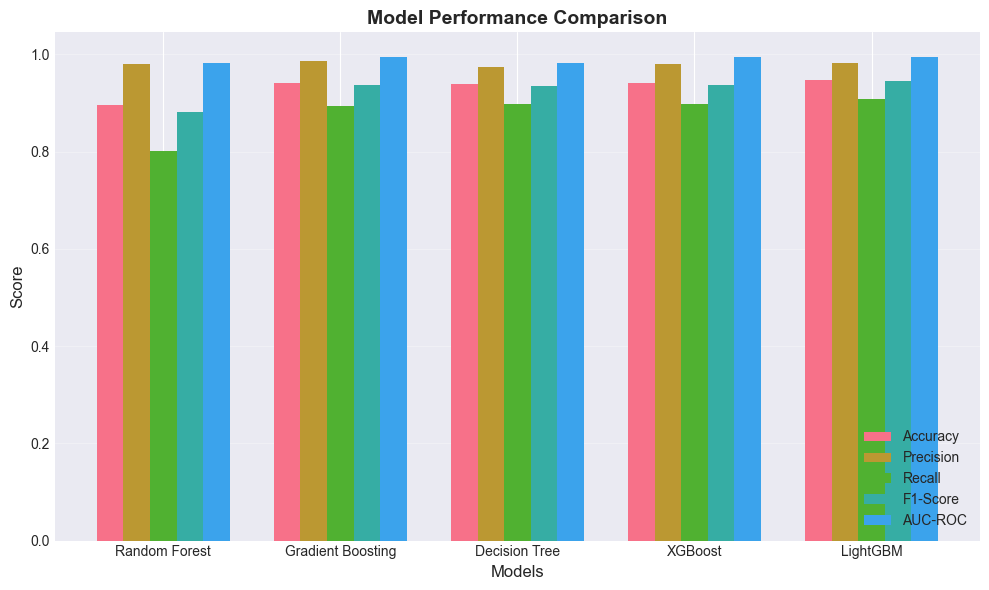

In [323]:
# Visualization 1: Model Performance Comparison

plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x + width * 2, results_df['Model'])
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

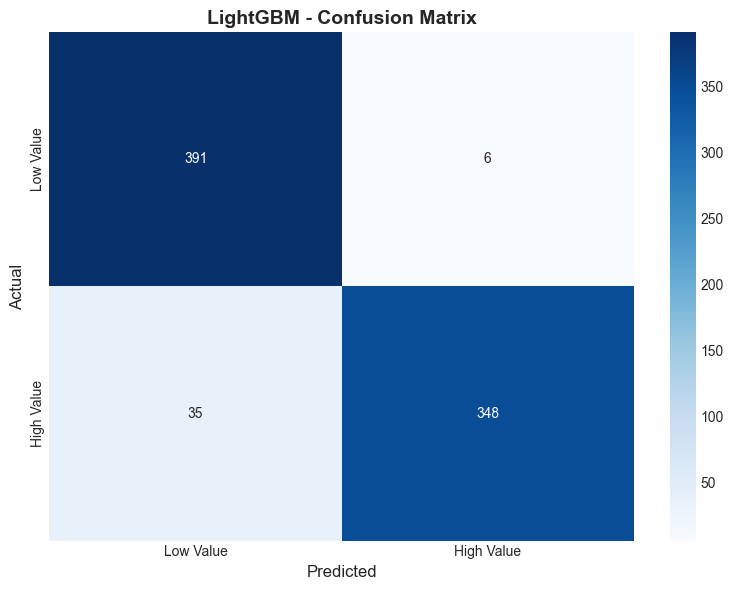


Confusion Matrix Interpretation:
True Negatives (Low→Low): 391
False Positives (Low→High): 6
False Negatives (High→Low): 35
True Positives (High→High): 348


In [324]:
# Visualization 2: Confusion Matrix for Best Model

best_model = models_dict[best_model_name]
preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Low Value', 'High Value'],
            yticklabels=['Low Value', 'High Value'])
plt.title(f'{best_model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Interpretation:")
print(f"True Negatives (Low→Low): {cm[0,0]}")
print(f"False Positives (Low→High): {cm[0,1]}")
print(f"False Negatives (High→Low): {cm[1,0]}")
print(f"True Positives (High→High): {cm[1,1]}")

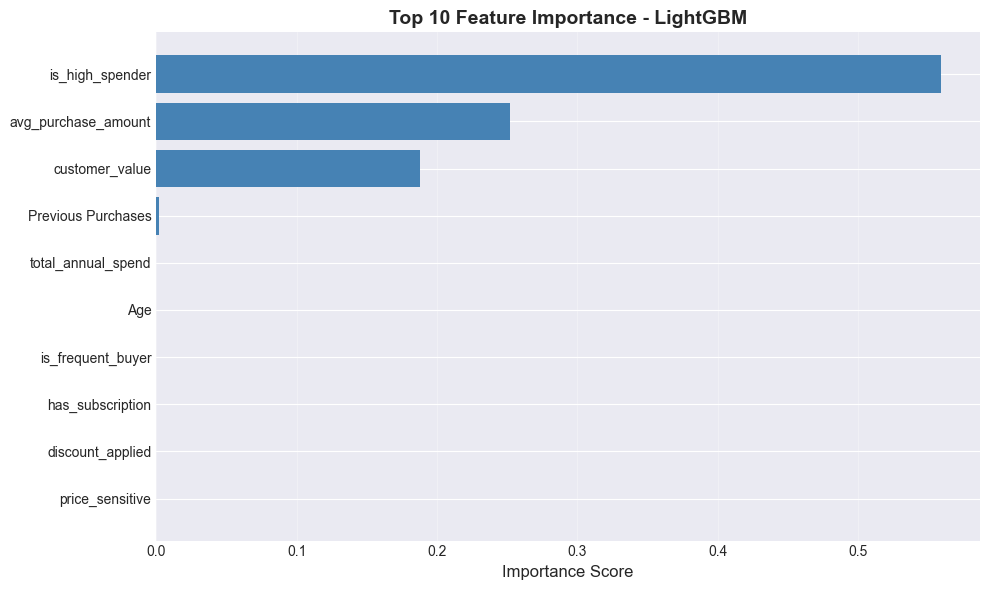


Top 5 Most Important Features:
1. is_high_spender: 0.5588
2. avg_purchase_amount: 0.2516
3. customer_value: 0.1880
4. Previous Purchases: 0.0017
5. total_annual_spend: 0.0000


In [ ]:
if best_model_name == 'Decision Tree':
    importances = dt_model.feature_importances_
elif best_model_name == 'Random Forest':
    importances = rf_model.feature_importances_
else:
    importances = gb_model.feature_importances_

feature_names = X.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Score', fontsize=12)
plt.title(f'Top 10 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features:")
for i, idx in enumerate(indices[-5:][::-1], 1):
    print(f"{i}. {feature_names[idx]}: {importances[idx]:.4f}")

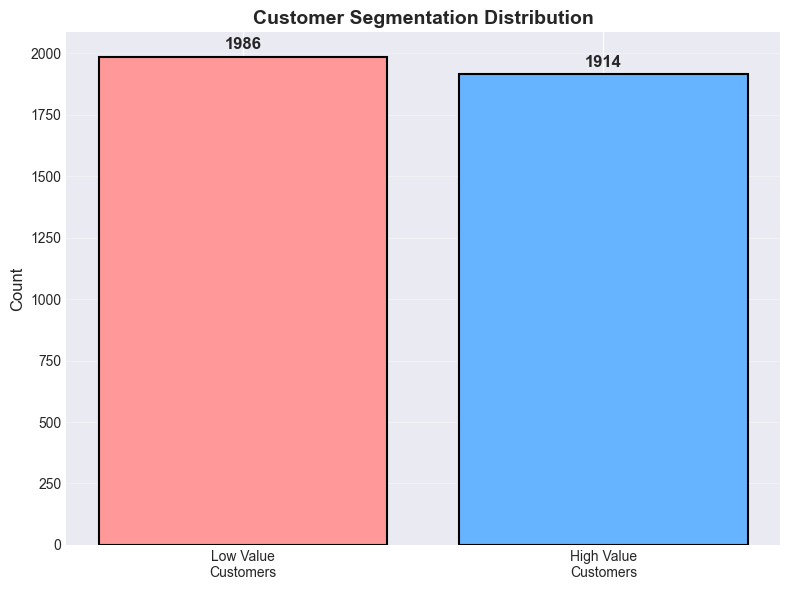

In [326]:
# Visualization 4: Target Class Distribution

plt.figure(figsize=(8, 6))
class_counts = y.value_counts()
colors = ['#ff9999', '#66b3ff']
plt.bar(['Low Value\nCustomers', 'High Value\nCustomers'], class_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Count', fontsize=12)
plt.title('Customer Segmentation Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
X_reg = df.drop(['Customer ID', 'Purchase Amount (USD)', 'target'], axis=1)
y_reg = df['Purchase Amount (USD)']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print("Training Linear Regression Model...")
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

r2 = r2_score(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"\n{'='*60}")
print("Regression Model Performance:")
print(f"{'='*60}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"{'='*60}")

reg_results = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE'],
    'Value': [r2, rmse, mae]
})
reg_results.to_csv('regression_results.csv', index=False)

Training Linear Regression Model...

Regression Model Performance:
R² Score: 0.8486
RMSE: $9.20
MAE: $7.26


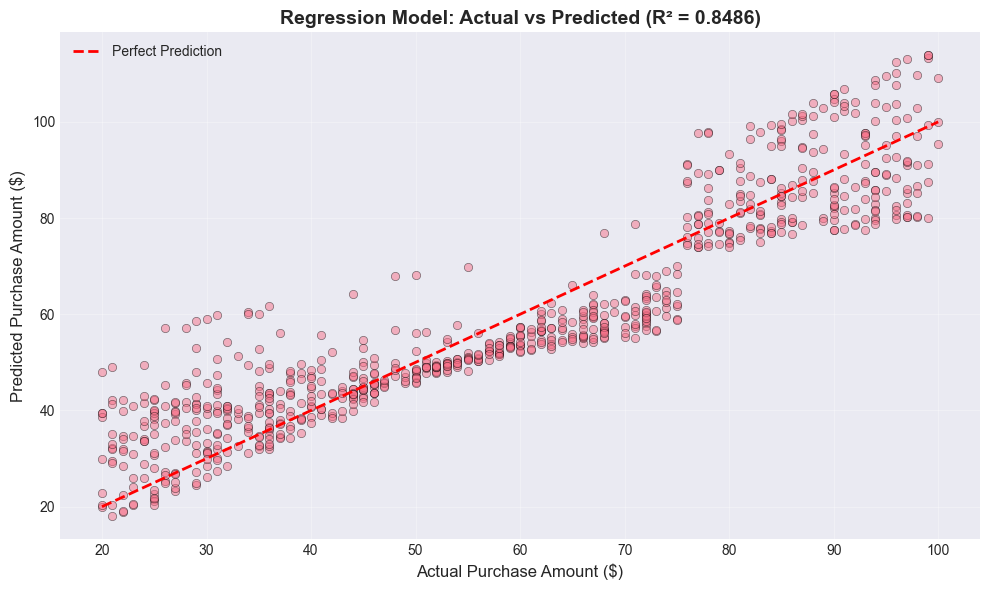

In [328]:
# Visualization 5: Regression Performance

plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Purchase Amount ($)', fontsize=12)
plt.ylabel('Predicted Purchase Amount ($)', fontsize=12)
plt.title(f'Regression Model: Actual vs Predicted (R² = {r2:.4f})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [329]:
# Final Summary and Business Insights

print("="*70)
print(" "*15 + "RETAIL PREDICTIVE ANALYTICS - FINAL SUMMARY")
print("="*70)

print(f"\n📊 DATASET:")
print(f"   • Total Customers: {len(df):,}")
print(f"   • Original Features: 18")
print(f"   • Engineered Features: 10")
print(f"   • Total Features: {len(df.columns)}")

print(f"\n🎯 CLASSIFICATION MODELS:")
for idx, row in results_df.iterrows():
    print(f"   • {row['Model']}:")
    print(f"     - Accuracy: {row['Accuracy']*100:.2f}%")
    print(f"     - F1-Score: {row['F1-Score']:.4f}")
    print(f"     - AUC-ROC: {row['AUC-ROC']:.4f}")

print(f"\n🏆 BEST CLASSIFICATION MODEL: {best_model_name}")
print(f"   F1-Score: {results_df.loc[best_idx, 'F1-Score']:.4f}")

print(f"\n📈 REGRESSION MODEL:")
print(f"   • R² Score: {r2:.4f}")
print(f"   • RMSE: ${rmse:.2f}")
print(f"   • MAE: ${mae:.2f}")

print(f"\n💼 BUSINESS INSIGHTS:")
high_value_count = (df['target'] == 1).sum()
low_value_count = (df['target'] == 0).sum()
print(f"   • High-Value Customers: {high_value_count:,} ({high_value_count/len(df)*100:.1f}%)")
print(f"   • Low-Value Customers: {low_value_count:,} ({low_value_count/len(df)*100:.1f}%)")
print(f"   • Median Purchase Amount: ${median_amt:.2f}")

print("\n" + "="*70)
print(" "*20 + "ANALYSIS COMPLETE!")
print("="*70)

               RETAIL PREDICTIVE ANALYTICS - FINAL SUMMARY

📊 DATASET:
   • Total Customers: 3,900
   • Original Features: 18
   • Engineered Features: 10
   • Total Features: 29

🎯 CLASSIFICATION MODELS:
   • Random Forest:
     - Accuracy: 89.49%
     - F1-Score: 0.8822
     - AUC-ROC: 0.9821
   • Gradient Boosting:
     - Accuracy: 94.10%
     - F1-Score: 0.9370
     - AUC-ROC: 0.9946
   • Decision Tree:
     - Accuracy: 93.85%
     - F1-Score: 0.9348
     - AUC-ROC: 0.9816
   • XGBoost:
     - Accuracy: 94.10%
     - F1-Score: 0.9373
     - AUC-ROC: 0.9941
   • LightGBM:
     - Accuracy: 94.74%
     - F1-Score: 0.9444
     - AUC-ROC: 0.9954

🏆 BEST CLASSIFICATION MODEL: LightGBM
   F1-Score: 0.9444

📈 REGRESSION MODEL:
   • R² Score: 0.8486
   • RMSE: $9.20
   • MAE: $7.26

💼 BUSINESS INSIGHTS:
   • High-Value Customers: 1,914 (49.1%)
   • Low-Value Customers: 1,986 (50.9%)
   • Median Purchase Amount: $60.00

                    ANALYSIS COMPLETE!


In [330]:
# Advanced Customer Lifetime Value (CLV) Analysis

print("="*70)
print("CUSTOMER LIFETIME VALUE (CLV) ANALYSIS")
print("="*70)

# CLV = (Average Purchase Value) × (Purchase Frequency) × (Customer Lifespan)

# Estimate customer lifespan based on subscription status
df['estimated_lifespan_years'] = df['has_subscription'].apply(lambda x: 5 if x == 1 else 2)

# Calculate CLV
df['CLV'] = df['avg_purchase_amount'] * df['purchase_freq'] * df['estimated_lifespan_years']

# Segment customers by CLV
df['CLV_segment'] = pd.cut(df['CLV'], 
                            bins=[0, 500, 2000, 5000, float('inf')],
                            labels=['Low CLV', 'Medium CLV', 'High CLV', 'Premium CLV'])

print(f"\nCustomer Lifetime Value Distribution:")
print(df['CLV_segment'].value_counts().sort_index())

print(f"\nCLV Statistics:")
print(f"   Mean CLV: ${df['CLV'].mean():.2f}")
print(f"   Median CLV: ${df['CLV'].median():.2f}")
print(f"   Max CLV: ${df['CLV'].max():.2f}")
print(f"   Min CLV: ${df['CLV'].min():.2f}")

top_clv = df.nlargest(10, 'CLV')[['Customer ID', 'CLV', 'avg_purchase_amount', 'purchase_freq', 'has_subscription']]
print(f"\n🏆 Top 10 Highest CLV Customers:")
print(top_clv.to_string(index=False))

CUSTOMER LIFETIME VALUE (CLV) ANALYSIS

Customer Lifetime Value Distribution:
CLV_segment
Low CLV        2961
Medium CLV      301
High CLV         48
Premium CLV       6
Name: count, dtype: int64

CLV Statistics:
   Mean CLV: $200.97
   Median CLV: $57.60
   Max CLV: $10270.00
   Min CLV: $0.00

🏆 Top 10 Highest CLV Customers:
 Customer ID     CLV  avg_purchase_amount  purchase_freq  has_subscription
         626 10270.0                 39.5           52.0                 1
         703  9230.0                 35.5           52.0                 1
         877  6630.0                 25.5           52.0                 1
         188  6110.0                 47.0           26.0                 1
         567  6045.0                 46.5           26.0                 1
        3528  5044.0                 48.5           52.0                 0
         413  4810.0                 18.5           52.0                 1
        1039  4810.0                 18.5           52.0               